In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap

In [2]:
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"

df_full = pd.read_csv(data_path, sep=';')

df_full.head()

# Filtra solo White-winged Scoter
df = df_full[df_full['species'] == 'WWSC'].copy()

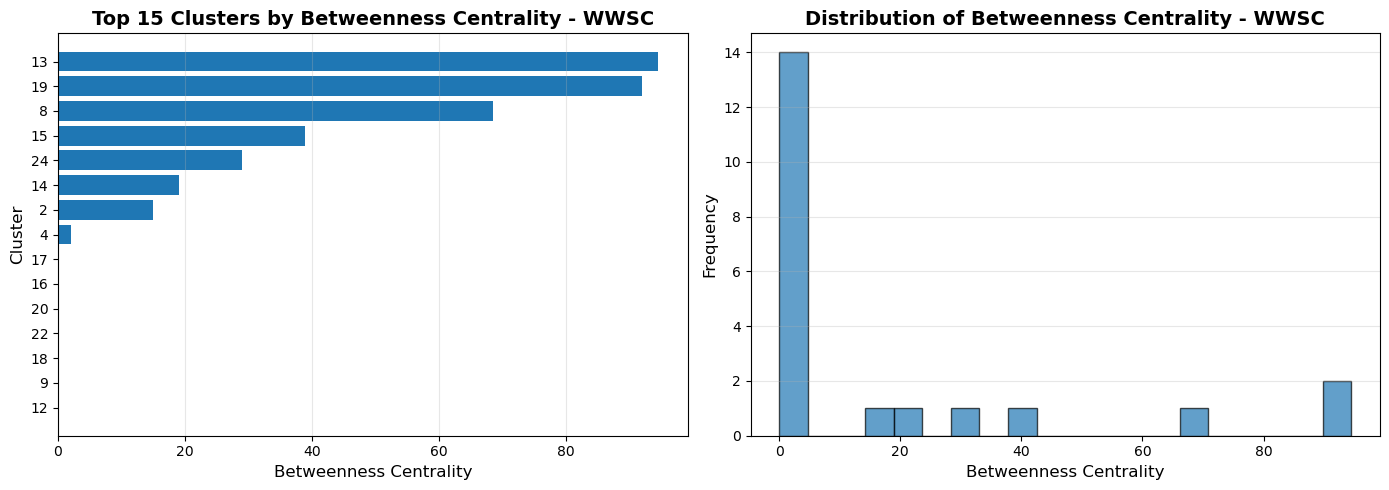

In [4]:
def calculate_global_betweenness(df, alpha=0.5):
 
    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
    

    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']
   
    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        source = int(row['source'])
        target = int(row['target'])
        weight = row['weight']
        
        distance = 1.0 / (weight ** alpha)
        
        G.add_edge(source, target, weight=weight, distance=distance)
    
    betweenness = nx.betweenness_centrality(
        G, 
        weight='distance',  
        normalized=False    
    )
    
    bc_df = pd.DataFrame([
        {'cluster': node, 'betweenness_centrality': bc}
        for node, bc in betweenness.items()
    ]).sort_values('betweenness_centrality', ascending=False)

    return bc_df, G, edge_weights


def plot_betweenness_results(bc_df, save_path=None):
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    top_clusters = bc_df.head(15)
    ax1.barh(top_clusters['cluster'].astype(str), top_clusters['betweenness_centrality'])
    ax1.set_xlabel('Betweenness Centrality', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by Betweenness Centrality - WWSC', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    ax2 = axes[1]
    ax2.hist(bc_df['betweenness_centrality'], bins=20, edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Betweenness Centrality', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Betweenness Centrality - WWSC', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()

bc_df, G, edge_weights = calculate_global_betweenness(df, alpha=0.5)

base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

plot_betweenness_results(bc_df, save_path=base_path + "betweenness_global_plot.png")



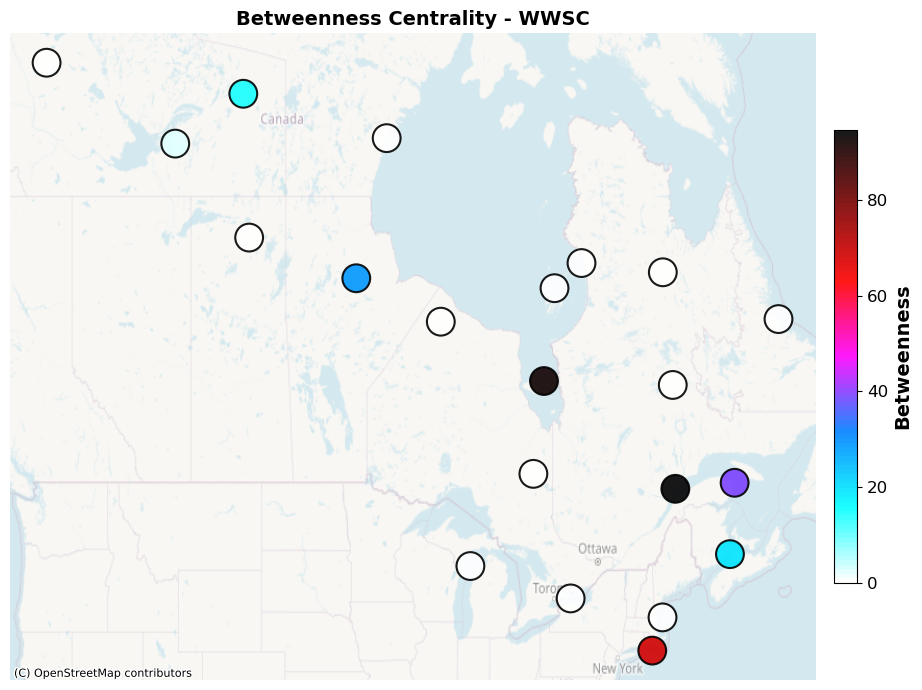

In [5]:

def plot_betweenness_map(df, bc_df, save_path=None):
 
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    cluster_data = cluster_coords.merge(bc_df, on='cluster')
  
    from pyproj import Transformer
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    
    x_coords, y_coords = transformer.transform(
        cluster_data['lon'].values,
        cluster_data['lat'].values
    )
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    fig, ax = plt.subplots(figsize=(10,7))
    
    colors = ['#FFFFFF', '#00FFFF', '#0080FF', '#FF00FF', '#FF0000', '#800000', '#000000']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('betweenness', colors, N=n_bins)
    
    bc_values = cluster_data['betweenness_centrality'].values
    
    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=bc_values,
        s=400,  
        cmap=cmap,
        vmin=0,
        vmax=bc_values.max(),
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.9
    )
    
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)
    
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    cbar.set_label('Betweenness', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    ax.set_title('Betweenness Centrality - WWSC', fontsize=14, fontweight='bold')
    
    ax.set_axis_off()
    
    plt.tight_layout()
    
    plt.show()


base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

plot_betweenness_map(
    df=df,
    bc_df=bc_df,
    save_path=base_path + "betweenness_map_fig4c.png"
)

   ✓ Movimenti validi: 388


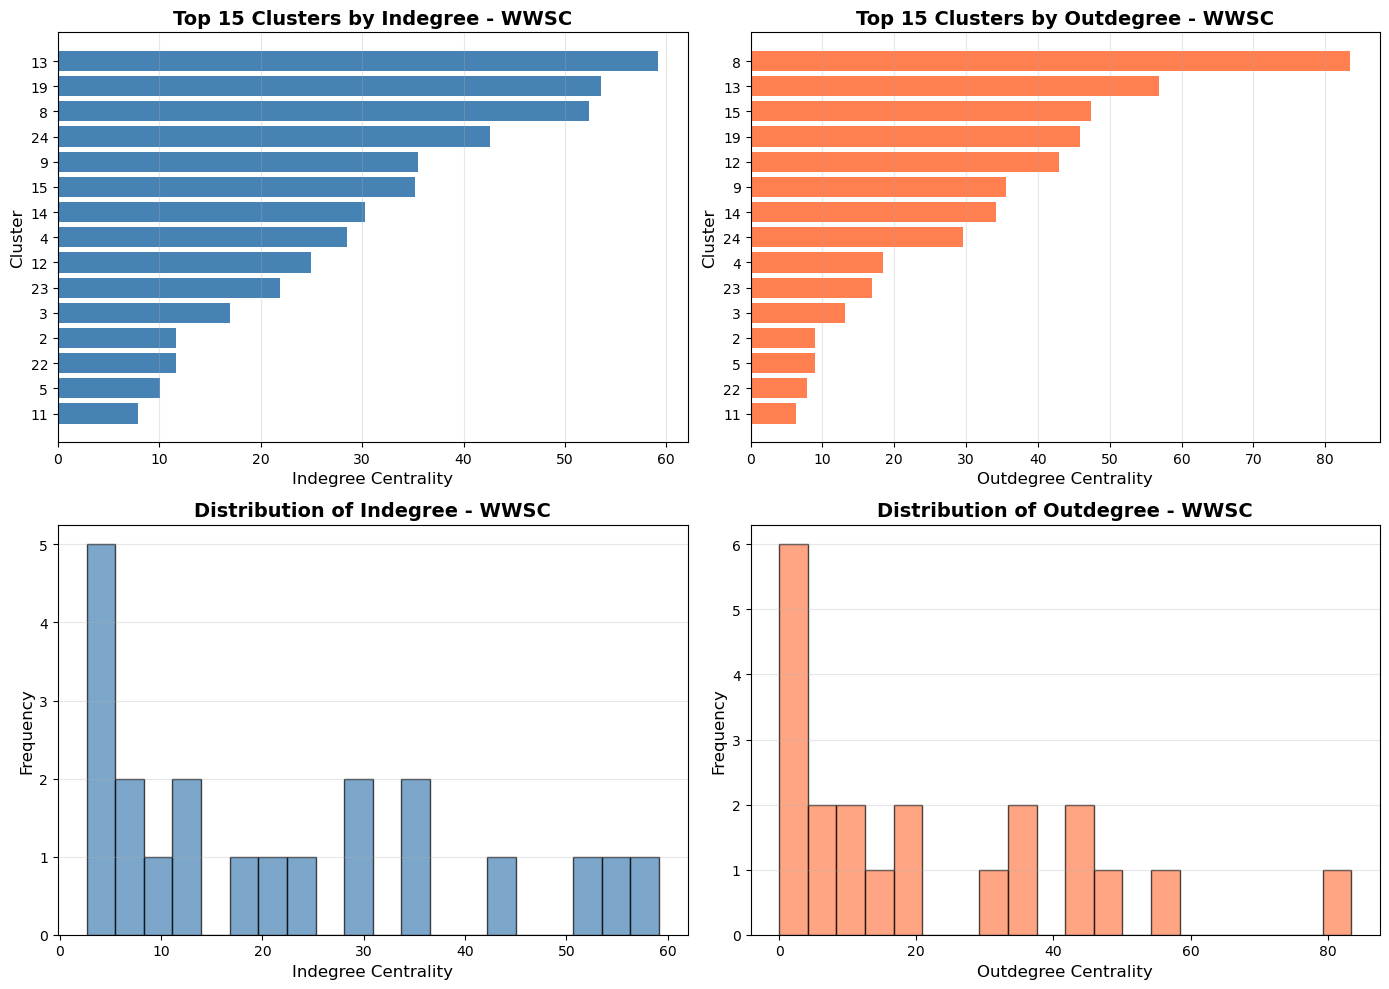

In [6]:
def calculate_degree_centrality(df, alpha=0.5):

    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
    print(f"   ✓ Movimenti validi: {len(df_valid)}")
    
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']

    edge_weights['weight_alpha'] = edge_weights['weight'] ** alpha
    
    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        G.add_edge(
            int(row['source']), 
            int(row['target']), 
            weight=row['weight'],
            weight_alpha=row['weight_alpha']
        )
   
    all_clusters = set(G.nodes())
    
    degree_data = []
    
    for cluster in all_clusters:
        # OUTDEGREE: somma dei pesi in uscita
        outdegree = sum(
            G[cluster][neighbor]['weight_alpha'] 
            for neighbor in G.successors(cluster)
        )
        
        # INDEGREE: somma dei pesi in entrata
        indegree = sum(
            G[predecessor][cluster]['weight_alpha'] 
            for predecessor in G.predecessors(cluster)
        )
        
        degree_data.append({
            'cluster': cluster,
            'indegree': indegree,
            'outdegree': outdegree,
            'total_degree': indegree + outdegree
        })
    
    degree_df = pd.DataFrame(degree_data)
    
    top_in = degree_df.nlargest(10, 'indegree')[['cluster', 'indegree']]

    top_out = degree_df.nlargest(10, 'outdegree')[['cluster', 'outdegree']]
  
    return degree_df, G, edge_weights


def plot_degree_centrality(degree_df, save_path=None):
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Indegree - Top 15
    ax1 = axes[0, 0]
    top_in = degree_df.nlargest(15, 'indegree')
    ax1.barh(top_in['cluster'].astype(str), top_in['indegree'], color='steelblue')
    ax1.set_xlabel('Indegree Centrality', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by Indegree - WWSC', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Outdegree - Top 15
    ax2 = axes[0, 1]
    top_out = degree_df.nlargest(15, 'outdegree')
    ax2.barh(top_out['cluster'].astype(str), top_out['outdegree'], color='coral')
    ax2.set_xlabel('Outdegree Centrality', fontsize=12)
    ax2.set_ylabel('Cluster', fontsize=12)
    ax2.set_title('Top 15 Clusters by Outdegree - WWSC', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    # Plot 3: Distribuzione Indegree
    ax3 = axes[1, 0]
    ax3.hist(degree_df['indegree'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax3.set_xlabel('Indegree Centrality', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Distribution of Indegree - WWSC', fontsize=14, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    
    # Plot 4: Distribuzione Outdegree
    ax4 = axes[1, 1]
    ax4.hist(degree_df['outdegree'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax4.set_xlabel('Outdegree Centrality', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    ax4.set_title('Distribution of Outdegree - WWSC', fontsize=14, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()

degree_df, G, edge_weights = calculate_degree_centrality(df, alpha=0.5)

base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

plot_degree_centrality(degree_df, save_path=base_path + "degree_centrality_plots.png")

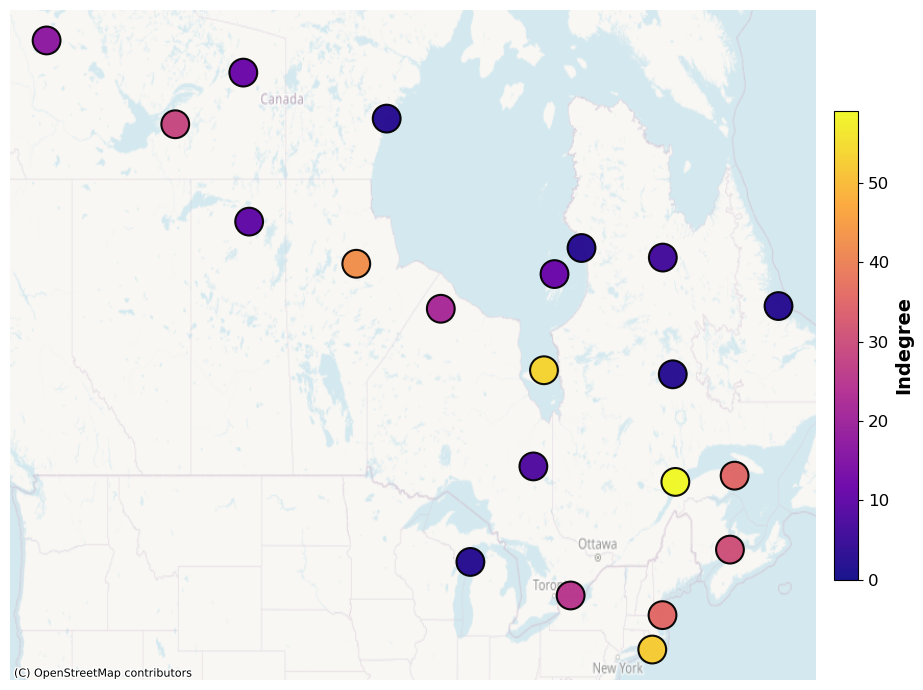

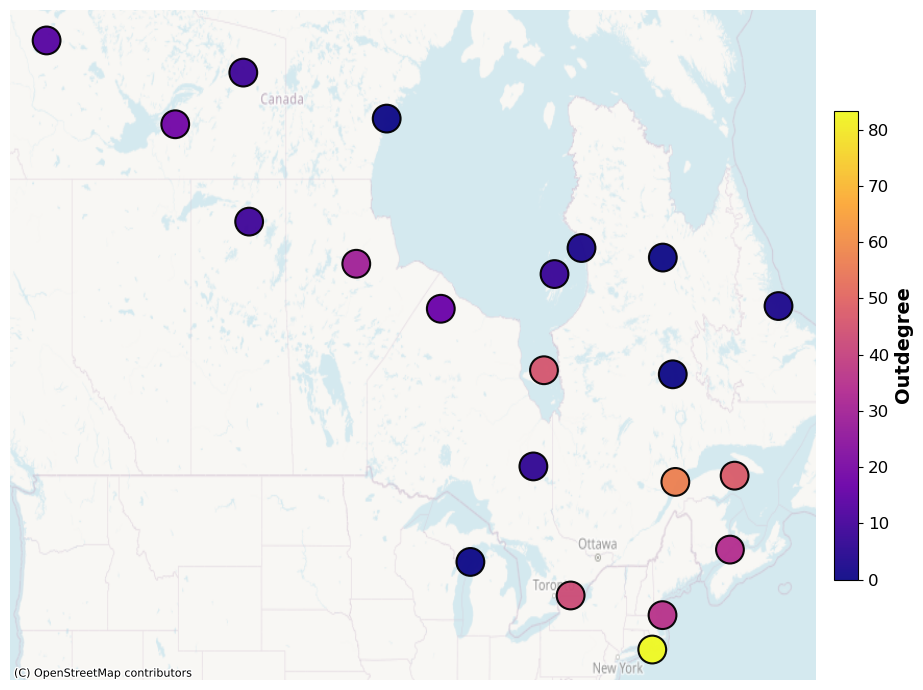

In [7]:
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap

def plot_degree_map(df, degree_df, metric='indegree'):
   
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    cluster_data = cluster_coords.merge(degree_df, on='cluster')
    
    def lat_lon_to_web_mercator(lon, lat):
     
        x = lon * 20037508.34 / 180
        y = np.log(np.tan((90 + lat) * np.pi / 360)) / (np.pi / 180)
        y = y * 20037508.34 / 180
        return x, y
    
    x_coords = []
    y_coords = []
    for _, row in cluster_data.iterrows():
        x, y = lat_lon_to_web_mercator(row['lon'], row['lat'])
        x_coords.append(x)
        y_coords.append(y)
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    colors = ['#0D0887', '#6A00A8', '#B12A90', '#E16462', '#FCA636', '#F0F921']
    cmap = LinearSegmentedColormap.from_list('degree', colors, N=256)
    
    values = cluster_data[metric].values
    
    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=values,
        s=400,
        cmap=cmap,
        vmin=0,
        vmax=values.max(),
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.95
    )

    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)
   
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    label = 'Indegree' if metric == 'indegree' else 'Outdegree'
    cbar.set_label(label, fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    ax.set_axis_off()
    
    plt.tight_layout()
    
    plt.show()

plot_degree_map(df, degree_df, metric='indegree')

plot_degree_map(df, degree_df, metric='outdegree')